In [1]:
# Download Char74K while eMNIST trains
!wget -q --show-progress http://www.ee.surrey.ac.uk/CVSSP/demos/chars74k/EnglishFnt.tgz
!tar -xzf EnglishFnt.tgz
!echo "Done"
!ls English/Fnt/ | head -10

EnglishFnt.tgz      100%[===================>]  47.51M  20.6MB/s    in 2.3s    
Done
Sample001
Sample002
Sample003
Sample004
Sample005
Sample006
Sample007
Sample008
Sample009
Sample010


In [2]:
# Download and verify Char74K — do this while CNN trains
import os
import glob

# Check if already downloaded
if os.path.exists("/content/English/Fnt/Sample001"):
    files = glob.glob("/content/English/Fnt/Sample001/*.png")
    print(f"Char74K already ready — {len(files)} images in Sample001")
else:
    print("Downloading Char74K...")
    os.system("wget -q --show-progress http://www.ee.surrey.ac.uk/CVSSP/demos/chars74k/EnglishFnt.tgz")
    os.system("tar -xzf EnglishFnt.tgz")
    files = glob.glob("/content/English/Fnt/Sample001/*.png")
    print(f"Done — {len(files)} images in Sample001")

Char74K already ready — 1016 images in Sample001


In [3]:
import os
import glob

CHAR74K_DIR = "/content/English/Fnt"

# Check a few sample folders
for i in [1, 11, 37]:
    folder = os.path.join(CHAR74K_DIR, f"Sample{i:03d}")
    files  = glob.glob(os.path.join(folder, "*"))
    print(f"Sample{i:03d} → {len(files)} images")

# Sample001 = '0' (digit)
# Sample011 = 'A' (uppercase)
# Sample037 = 'a' (lowercase)

Sample001 → 1016 images
Sample011 → 1016 images
Sample037 → 1016 images


In [4]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

# UPDATE THESE if your paths differ
EMNIST_WEIGHTS  = "/content/drive/MyDrive/OCR/emnist_cnn_byclass_2.pth"
UNET_WEIGHTS    = "/content/drive/MyDrive/OCR/Dataset/unet_denoiser_best.pth"
CHAR74K_SAVE    = "/content/drive/MyDrive/OCR/char74k_finetuned_cnn.pth"
CHAR74K_DIR     = "/content/English/Fnt"   # path after extraction

for path, name in [
    (EMNIST_WEIGHTS, "eMNIST weights"),
    (UNET_WEIGHTS,   "U-Net weights"),
]:
    status = "OK" if os.path.exists(path) else "NOT FOUND — update path"
    print(f"  [{status}] {name}")


  [OK] eMNIST weights
  [OK] U-Net weights


In [6]:

import cv2
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from PIL import Image

try:
    from skimage.filters import threshold_sauvola
    SKIMAGE_AVAILABLE = True
except ImportError:
    SKIMAGE_AVAILABLE = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [8]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, groups=8):
        super().__init__()
        g = min(groups, out_ch)
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(g, out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(g, out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size=1)
        )
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:],
                              mode='bilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


In [9]:
class UNetDenoiser(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()
        b = base_ch
        self.enc1 = ConvBlock(in_ch, b)
        self.enc2 = ConvBlock(b,     b*2)
        self.enc3 = ConvBlock(b*2,   b*4)
        self.neck = ConvBlock(b*4,   b*8)
        self.pool = nn.MaxPool2d(2)
        self.dec3 = UpBlock(b*8, b*4, b*4)
        self.dec2 = UpBlock(b*4, b*2, b*2)
        self.dec1 = UpBlock(b*2, b,   b)
        self.out_conv = nn.Conv2d(b, out_ch, kernel_size=1)
    def forward(self, x):
        inp = x
        e1  = self.enc1(x)
        e2  = self.enc2(self.pool(e1))
        e3  = self.enc3(self.pool(e2))
        n   = self.neck(self.pool(e3))
        d3  = self.dec3(n,  e3)
        d2  = self.dec2(d3, e2)
        d1  = self.dec1(d2, e1)
        return torch.clamp(inp - self.out_conv(d1), 0.0, 1.0)




In [10]:
class CharCNN(nn.Module):
    def __init__(self, num_classes=62):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout(0.1),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout(0.15),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Dropout(0.2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*7*7, 256), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))



In [11]:
emnist_ckpt  = torch.load(EMNIST_WEIGHTS, map_location=device, weights_only=False)
NUM_CLASSES  = emnist_ckpt["num_classes"]   # 62
EMNIST_CHARS = emnist_ckpt["classes"]       # ['0'..'9','A'..'Z','a'..'z']
IDX_TO_CHAR  = {i: ch for i, ch in enumerate(EMNIST_CHARS)}
CHAR_TO_IDX  = {ch: i for i, ch in enumerate(EMNIST_CHARS)}

print(f"NUM_CLASSES:  {NUM_CLASSES}")
print(f"Sample chars: {EMNIST_CHARS[:10]} ... {EMNIST_CHARS[-5:]}")

NUM_CLASSES:  62
Sample chars: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'] ... ['v', 'w', 'x', 'y', 'z']


In [7]:
class Char74KDataset(Dataset):
    def __init__(self, root_dir, augment=False, size=28):
        self.size    = size
        self.augment = augment
        self.samples = []

        self.aug = T.Compose([
            T.ToPILImage(),
            T.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.85, 1.15)),
            T.RandomApply([T.GaussianBlur(3, sigma=(0.1, 1.0))], p=0.3),
            T.ToTensor(),
        ])

        for sample_idx in range(1, 63):
            folder = os.path.join(root_dir, f"Sample{sample_idx:03d}")
            if not os.path.exists(folder):
                continue
            label  = sample_idx - 1
            images = (glob.glob(os.path.join(folder, "*.png")) +
                      glob.glob(os.path.join(folder, "*.jpg")) +
                      glob.glob(os.path.join(folder, "*.bmp")))
            for img_path in images:
                self.samples.append((img_path, label))

        print(f"Char74K loaded: {len(self.samples)} samples | "
              f"{len(set(s[1] for s in self.samples))} classes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
      img_path, label = self.samples[idx]
      img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
      if img is None:
          return torch.zeros(1, self.size, self.size), label
      img   = cv2.resize(img, (self.size, self.size), interpolation=cv2.INTER_AREA)
      img   = 255 - img          # invert only — no rotation
      img_t = torch.from_numpy(img).unsqueeze(0)
      if self.augment:
          img_t = self.aug(img_t).squeeze(0).unsqueeze(0)
      img_f = img_t.float() / 255.0
      img_f = (img_f - 0.1736) / 0.3317
      return img_f, torch.tensor(label, dtype=torch.long)

In [12]:
full_ds   = Char74KDataset(CHAR74K_DIR, augment=True)
val_size  = max(1, int(0.15 * len(full_ds)))
train_size = len(full_ds) - val_size
train_ds, val_ds = random_split(
    full_ds, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
val_ds.dataset.augment = False

Char74K loaded: 62992 samples | 62 classes


In [13]:
# Balanced sampler — Char74K has unequal samples per class
all_labels    = np.array([full_ds.samples[i][1] for i in range(len(full_ds))])
class_counts  = np.bincount(all_labels, minlength=NUM_CLASSES)
class_counts  = np.where(class_counts == 0, 1, class_counts)
class_weights = 1.0 / class_counts
train_labels  = all_labels[[i for i in train_ds.indices]]
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(sample_weights),
    replacement=True
)

Train: 53544 | Val: 9448


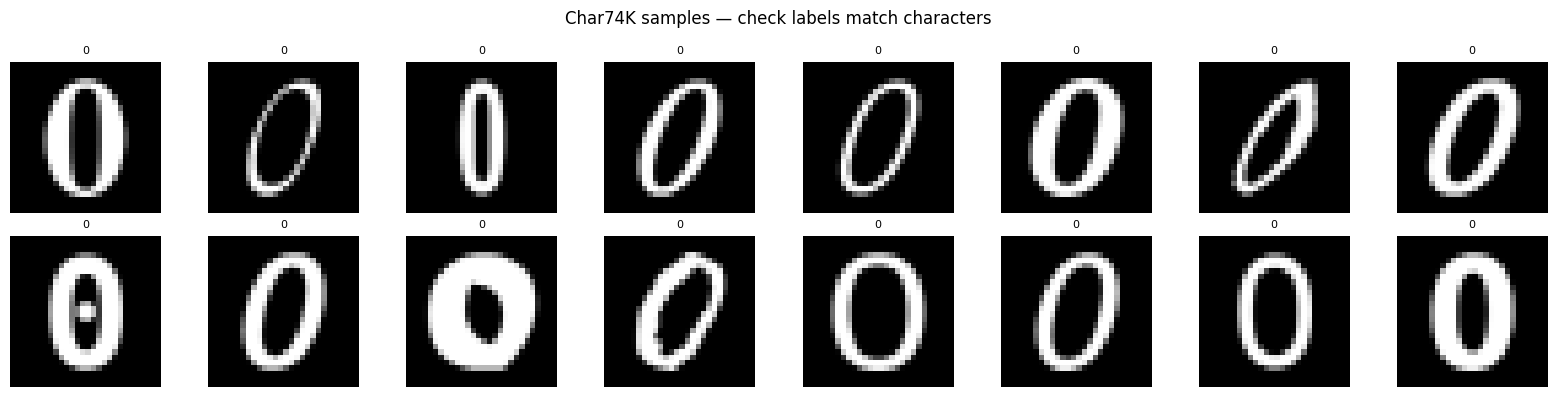

In [14]:
train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,    num_workers=2)
print(f"Train: {train_size} | Val: {val_size}")

# Visualise a few samples to confirm loading is correct
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img, label = full_ds[i]
    img = img.squeeze().numpy() * 0.5 + 0.5  # unnormalise
    ax.imshow(img, cmap='gray')
    ax.set_title(EMNIST_CHARS[label] if label < len(EMNIST_CHARS) else str(label),
                 fontsize=8)
    ax.axis('off')
plt.suptitle('Char74K samples — check labels match characters')
plt.tight_layout()
plt.show()

In [15]:
ft_model = CharCNN(NUM_CLASSES).to(device)
ft_model.load_state_dict(emnist_ckpt["model_state_dict"])
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        if is_train:
            optimizer.zero_grad()
        with torch.set_grad_enabled(is_train):
            out  = model(imgs)
            loss = criterion(out, labels)
            if is_train:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


In [16]:
# Phase 1 — freeze feature extractor, train head only
for param in ft_model.features.parameters():
    param.requires_grad = False

opt_head = optim.Adam(
    filter(lambda p: p.requires_grad, ft_model.parameters()), lr=1e-3
)
print("Phase 1 — head only (5 epochs)")
for epoch in range(1, 6):
    tr_loss, tr_acc = run_epoch(ft_model, train_loader, opt_head)
    vl_loss, vl_acc = run_epoch(ft_model, val_loader)
    print(f"  Epoch {epoch}/5 | Train: {tr_acc:.3f} | Val: {vl_acc:.3f}")


Phase 1 — head only (5 epochs)
  Epoch 1/5 | Train: 0.846 | Val: 0.874
  Epoch 2/5 | Train: 0.876 | Val: 0.889
  Epoch 3/5 | Train: 0.884 | Val: 0.890
  Epoch 4/5 | Train: 0.895 | Val: 0.894
  Epoch 5/5 | Train: 0.898 | Val: 0.895


In [17]:

# Phase 2 — unfreeze all, full fine-tune
for param in ft_model.features.parameters():
    param.requires_grad = True

opt_full   = optim.Adam(ft_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(opt_full, T_max=20)
best_acc   = 0.0
no_improve = 0
PATIENCE   = 5

print("\nPhase 2 — full fine-tune (max 20 epochs, patience 5)")
for epoch in range(1, 21):
    tr_loss, tr_acc = run_epoch(ft_model, train_loader, opt_full)
    vl_loss, vl_acc = run_epoch(ft_model, val_loader)
    scheduler.step()

    print(f"  Epoch {epoch:02d}/20 | Train: {tr_acc:.3f} | Val: {vl_acc:.3f}")

    if vl_acc > best_acc:
        best_acc   = vl_acc
        no_improve = 0
        torch.save({
            "model_state_dict": ft_model.state_dict(),
            "num_classes":      NUM_CLASSES,
            "classes":          EMNIST_CHARS,
            "val_acc":          vl_acc,
            "trained_on":       "emnist_byclass + char74k_fnt",
        }, CHAR74K_SAVE)
        print(f"    --> Saved (val_acc={vl_acc:.3f})")
    else:
        no_improve += 1
        print(f"    No improvement {no_improve}/{PATIENCE}")
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

print(f"\nBest val acc: {best_acc:.3f}")
print(f"Saved to: {CHAR74K_SAVE}")



Phase 2 — full fine-tune (max 20 epochs, patience 5)
  Epoch 01/20 | Train: 0.913 | Val: 0.910
    --> Saved (val_acc=0.910)
  Epoch 02/20 | Train: 0.919 | Val: 0.912
    --> Saved (val_acc=0.912)
  Epoch 03/20 | Train: 0.919 | Val: 0.912
    --> Saved (val_acc=0.912)
  Epoch 04/20 | Train: 0.925 | Val: 0.916
    --> Saved (val_acc=0.916)
  Epoch 05/20 | Train: 0.926 | Val: 0.918
    --> Saved (val_acc=0.918)
  Epoch 06/20 | Train: 0.929 | Val: 0.919
    --> Saved (val_acc=0.919)
  Epoch 07/20 | Train: 0.930 | Val: 0.919
    --> Saved (val_acc=0.919)
  Epoch 08/20 | Train: 0.930 | Val: 0.919
    No improvement 1/5
  Epoch 09/20 | Train: 0.932 | Val: 0.921
    --> Saved (val_acc=0.921)
  Epoch 10/20 | Train: 0.935 | Val: 0.920
    No improvement 1/5
  Epoch 11/20 | Train: 0.937 | Val: 0.922
    --> Saved (val_acc=0.922)
  Epoch 12/20 | Train: 0.937 | Val: 0.918
    No improvement 1/5
  Epoch 13/20 | Train: 0.939 | Val: 0.922
    --> Saved (val_acc=0.922)
  Epoch 14/20 | Train: 0.940 | 

In [123]:
@torch.no_grad()
def denoise_image(model, image, device):
    if image.ndim == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    h, w       = image.shape
    img_norm   = image.astype(np.float32) / 255.0
    pad_h      = (8 - h % 8) % 8
    pad_w      = (8 - w % 8) % 8
    img_padded = np.pad(img_norm, ((0, pad_h), (0, pad_w)), mode='reflect')
    tensor     = torch.from_numpy(img_padded).unsqueeze(0).unsqueeze(0).to(device)
    output     = model(tensor).squeeze().cpu().numpy()
    return (output[:h, :w] * 255).clip(0, 255).astype(np.uint8)


def preprocess_for_segmentation(gray, method="sauvola", use_dilation=False):
    if len(gray.shape) == 3:
        gray = cv2.cvtColor(gray, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    if method == "sauvola" and SKIMAGE_AVAILABLE:
        thresh = threshold_sauvola(blur, window_size=25, k=0.2)
        binary = (blur < thresh).astype(np.uint8) * 255
    else:
        _, binary = cv2.threshold(
            blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
        )
    kernel = np.ones((2, 2), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    if np.sum(binary == 255) > np.sum(binary == 0):
        binary = 255 - binary
    return binary

    # ── Auto-scale ────────────────────────────────────────────
    if est_char_h < min_char_height:
        scale  = min_char_height / est_char_h
        action = "Upscaled"
    elif est_char_h > max_char_height:
        scale  = max_char_height / est_char_h
        action = "Downscaled"
    else:
        scale  = 1.0
        action = "No scaling needed"

    if scale != 1.0:
        new_w = int(gray.shape[1] * scale)
        new_h = int(gray.shape[0] * scale)
        interp = cv2.INTER_CUBIC if scale > 1 else cv2.INTER_AREA
        gray   = cv2.resize(gray, (new_w, new_h), interpolation=interp)
        print(f"  {action} {scale:.2f}x — char height {est_char_h:.0f}px → {est_char_h*scale:.0f}px")
    else:
        print(f"  {action} — char height {est_char_h:.0f}px")

    # ── Binarize ──────────────────────────────────────────────
    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    if method == "sauvola" and SKIMAGE_AVAILABLE:
        thresh = threshold_sauvola(blur, window_size=25, k=0.2)
        binary = (blur < thresh).astype(np.uint8) * 255
    else:
        _, binary = cv2.threshold(
            blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
        )
    kernel = np.ones((2, 2), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # Force white text on black
    if np.sum(binary == 255) > np.sum(binary == 0):
        binary = 255 - binary

    return binary


def segment_lines(binary, min_line_height=10, row_frac=0.01):
    row_sum          = np.sum(binary > 0, axis=1)
    min_black_pixels = max(3, int(row_frac * binary.shape[1]))
    lines, in_line, start = [], False, 0
    for y, val in enumerate(row_sum):
        if not in_line and val >= min_black_pixels:
            in_line, start = True, y
        elif in_line and val < min_black_pixels:
            if y - start >= min_line_height:
                lines.append((start, y))
            in_line = False
    if in_line and (len(row_sum) - start) >= min_line_height:
        lines.append((start, len(row_sum)))
    return lines


def split_wide_box(line_binary, box, split_val_frac=0.15):
    x, y, w, h   = box
    col_sum      = np.sum(line_binary[y:y+h, x:x+w] > 0, axis=0)
    threshold    = max(1, int(split_val_frac * h))
    split_points = [i for i in range(1, len(col_sum)-1)
                    if col_sum[i] <= threshold
                    and col_sum[i-1] > threshold
                    and col_sum[i+1] > threshold]
    if not split_points:
        return [box]
    boxes, prev = [], 0
    for sp in split_points:
        if sp - prev > 2:
            boxes.append((x + prev, y, sp - prev, h))
        prev = sp
    if w - prev > 2:
        boxes.append((x + prev, y, w - prev, h))
    return boxes if len(boxes) > 1 else [box]


def segment_characters_in_line(line_binary, min_area=40, min_w=4,
                                min_h=8, max_w_ratio=0.18):
    contours, _ = cv2.findContours(
        line_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    H, W  = line_binary.shape
    boxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w*h < min_area or w < min_w or h < min_h:
            continue
        if w > 0.5*W and h < 0.35*H:
            continue
        boxes.append((x, y, w, h))
    boxes.sort(key=lambda b: b[0])
    final = []
    for box in boxes:
        x, y, w, h = box
        final.extend(
            split_wide_box(line_binary, box) if w > max_w_ratio*W else [box]
        )
    return sorted(final, key=lambda b: b[0])


def extract_character_crops(gray, binary, pad=1):
    H, W    = binary.shape
    results = []
    for (ly1, ly2) in segment_lines(binary):
        char_boxes_local  = segment_characters_in_line(binary[ly1:ly2, :])
        char_boxes_global = []
        char_crops        = []
        for (x, y, w, h) in char_boxes_local:
            x1 = max(0, x - pad)
            y1 = max(0, ly1 + y - pad)
            x2 = min(W, x + w + pad)
            y2 = min(H, ly1 + y + h + pad)
            char_boxes_global.append((x1, y1, x2, y2))
            char_crops.append(gray[y1:y2, x1:x2])
        results.append({
            "line_box":   (ly1, ly2),
            "char_boxes": char_boxes_global,
            "char_crops": char_crops,
        })
    return results

def prepare_char_crop(crop, size=28, invert=False):
    if crop is None or crop.size == 0:
        return np.zeros((size, size), dtype=np.float32)
    h, w     = crop.shape
    scale    = min((size-4)/max(h,1), (size-4)/max(w,1))
    new_w    = max(1, int(w * scale))
    new_h    = max(1, int(h * scale))
    resized  = cv2.resize(crop, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas   = np.zeros((size, size), dtype=np.uint8)
    y_off    = (size - new_h) // 2
    x_off    = (size - new_w) // 2
    canvas[y_off:y_off+new_h, x_off:x_off+new_w] = resized
    if invert:
        canvas = 255 - canvas
    # Contrast stretch
    min_val = canvas.min()
    max_val = canvas.max()
    if max_val > min_val:
        canvas = ((canvas - min_val) / (max_val - min_val) * 255).astype(np.uint8)
    img_f = canvas.astype(np.float32) / 255.0
    return (img_f - 0.1736) / 0.3317


def reconstruct_line_with_spaces(char_boxes, predictions, space_multiplier=1.8):
    if not char_boxes or not predictions:
        return ""

    widths   = [x2 - x1 for (x1, y1, x2, y2) in char_boxes]
    median_w = float(np.median(widths)) if widths else 10.0

    # Compute all gaps
    gaps = []
    for i in range(1, len(char_boxes)):
        prev_x2 = char_boxes[i-1][2]
        curr_x1 = char_boxes[i][0]
        gaps.append(curr_x1 - prev_x2)

    if not gaps:
        return "".join(predictions)

    # Dynamic threshold — use gap distribution instead of fixed multiplier
    # Find natural break between inter-char gaps and inter-word gaps
    gaps_arr   = np.array(gaps)
    max_gap    = gaps_arr.max()
    min_gap    = gaps_arr.min()

    # If max gap is clearly larger than others, use midpoint as threshold
    # Otherwise fall back to space_multiplier × median_width
    sorted_gaps = np.sort(gaps_arr)
    if len(sorted_gaps) > 3:
        # Look for a jump in gap sizes — word gaps are significantly larger
        diffs       = np.diff(sorted_gaps)
        jump_idx    = np.argmax(diffs)
        jump_size   = diffs[jump_idx]

        if jump_size > 3:  # there is a meaningful jump
            space_threshold = (sorted_gaps[jump_idx] + sorted_gaps[jump_idx+1]) / 2
        else:
            space_threshold = space_multiplier * median_w
    else:
        space_threshold = space_multiplier * median_w

    print(f"  Space threshold: {space_threshold:.1f}px (max gap: {max_gap:.1f}px)")

    result = [predictions[0]]
    for i in range(1, len(char_boxes)):
        prev_x2 = char_boxes[i-1][2]
        curr_x1 = char_boxes[i][0]
        gap     = curr_x1 - prev_x2
        if gap > space_threshold:
            result.append(" ")
        result.append(predictions[i])

    return "".join(result)


print("Inference helpers defined.")


Inference helpers defined.


In [124]:
# Load U-Net denoiser
unet_model = UNetDenoiser().to(device)
unet_ckpt  = torch.load(UNET_WEIGHTS, map_location=device, weights_only=False)
unet_model.load_state_dict(unet_ckpt["model_state_dict"])
unet_model.eval()
print("U-Net loaded")

# Load fine-tuned CNN
cnn_model = CharCNN(NUM_CLASSES).to(device)
cnn_ckpt  = torch.load(CHAR74K_SAVE, map_location=device, weights_only=False)
cnn_model.load_state_dict(cnn_ckpt["model_state_dict"])
cnn_model.eval()
print(f"CNN loaded — trained on: {cnn_ckpt.get('trained_on', 'unknown')}")


@torch.no_grad()
def run_ocr(image_path, unet_model, cnn_model, device,
            space_multiplier=1.8, show=True):
    raw = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if raw is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")

    # Stage 1 — denoise
    denoised = denoise_image(unet_model, raw, device)

    # Stage 2 — binarize + segment
    binary = preprocess_for_segmentation(
        denoised, method="sauvola", use_dilation=False  # ← change 1: no dilation, keeps strokes thin
    )
    seg = extract_character_crops(binary, binary)  # ← change 2: crops from binary not grayscale

    if show:
        vis = cv2.cvtColor(denoised, cv2.COLOR_GRAY2BGR)
        for line in seg:
            for (x1, y1, x2, y2) in line["char_boxes"]:
                cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 1)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].imshow(raw,          cmap="gray"); axes[0].set_title("Original");  axes[0].axis("off")
        axes[1].imshow(denoised,     cmap="gray"); axes[1].set_title("Denoised");  axes[1].axis("off")
        axes[2].imshow(vis[:,:,::-1]);             axes[2].set_title("Segmented"); axes[2].axis("off")
        plt.tight_layout()
        plt.show()

    lines_out, total_chars, all_confs = [], 0, []

    for line in seg:
        char_boxes = line["char_boxes"]
        preds      = []
        for crop in line["char_crops"]:
            prepared = prepare_char_crop(crop, invert=False)  # ← change 3: binary already white on black
            tensor   = torch.tensor(prepared, dtype=torch.float32)\
                           .unsqueeze(0).unsqueeze(0).to(device)
            probs    = torch.softmax(cnn_model(tensor), dim=1)
            conf, idx = probs.max(dim=1)
            all_confs.append(conf.item())
            preds.append(IDX_TO_CHAR.get(idx.item(), "?"))
            total_chars += 1
        line_text = reconstruct_line_with_spaces(
            char_boxes, preds, space_multiplier=space_multiplier
        )
        lines_out.append(line_text)

    full_text = "\n".join(lines_out)
    mean_conf = float(np.mean(all_confs)) if all_confs else 0.0

    print("── OCR Output ──────────────────────────────")
    print(full_text)
    print(f"\n── Metrics ─────────────────────────────────")
    print(f"  Lines:           {len(lines_out)}")
    print(f"  Characters:      {total_chars}")
    print(f"  Mean confidence: {mean_conf:.1%}")

    return {
        "text":            full_text,
        "lines":           len(lines_out),
        "characters":      total_chars,
        "mean_confidence": round(mean_conf, 4),
    }

U-Net loaded
CNN loaded — trained on: emnist_byclass + char74k_fnt


In [67]:
from google.colab import files

print("Upload any printed document image:")
uploaded  = files.upload()
img_path  = list(uploaded.keys())[0]

result = run_ocr(
    img_path,
    unet_model,
    cnn_model,
    device,
    space_multiplier=1.8,
    show=True,
)

# Tune space_multiplier if spacing looks wrong:
#   too few spaces  → lower to 1.5
#   too many spaces → raise to 2.2

Upload any printed document image:


KeyboardInterrupt: 

In [29]:
# Test with raw eMNIST weights — no Char74K fine-tuning
cnn_model = CharCNN(62).to(device)
emnist_ckpt = torch.load(
    "/content/drive/MyDrive/OCR/emnist_cnn_byclass_2.pth",
    map_location=device, weights_only=False
)
cnn_model.load_state_dict(emnist_ckpt["model_state_dict"])
cnn_model.eval()
EMNIST_CHARS = emnist_ckpt["classes"]
IDX_TO_CHAR  = {i: ch for i, ch in enumerate(EMNIST_CHARS)}
print("eMNIST weights loaded — no fine-tuning")

# Run inference
test_path = "/content/drive/MyDrive/OCR/Dataset/clean_images_grayscale/FontLre_Clean_TE.png"
raw      = cv2.imread(test_path, cv2.IMREAD_GRAYSCALE)
denoised = denoise_image(unet_model, raw, device)
binary   = preprocess_for_segmentation(denoised, method="sauvola", use_dilation=True)
seg      = extract_character_crops(denoised, binary)

lines_out = []
for line in seg:
    preds = []
    for crop in line["char_crops"]:
        prepared = prepare_char_crop(crop, invert=True)
        tensor   = torch.tensor(prepared, dtype=torch.float32)\
                       .unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            probs     = torch.softmax(cnn_model(tensor), dim=1)
            conf, idx = probs.max(dim=1)
        preds.append(IDX_TO_CHAR.get(idx.item(), "?"))
    line_text = reconstruct_line_with_spaces(
        line["char_boxes"], preds, space_multiplier=1.8
    )
    lines_out.append(line_text)

print("\n".join(lines_out))

eMNIST weights loaded — no fine-tuning
MMMMMMMMMAMMMMBMMMMMMMMMMQAMMMMMMMAMMMBGMBMMM
MMAMMMA MMMBMMBMAMAMMAMMMMMMMMDDMMMMMMMMBMMAMMBAM
MBMMAMMABMAMBM ABMMMMMMMMMMMMMMMMMMAMMMBGMD
MMMMMMGMBMBBMABAQAMMMMMMMMMMMMMMBMMQMMMMM
MMMAMQAMMWMMMMAMMMMMMMBMAMMMBMAMQMMMMMMMMBBMMM
MAMMMMMAMMMAMMMMMMGAMMMMMAQMMAMMMMMMMMMMMMM
MMMMMMMMMMMMMMMAMMMMMMMMMMMAMMMMMMMMMMMMMMAMMMM
MMMMMMMBMMMMQMBGAMMMMMMGAMMAMMMMBMMBMMMA
BMABAQMAMMBMMMMAMMMMMBMMMMQQAMMMMMMMMM
MMMMMMMMMAMMDQBMMMMAMMDMMMMMMMMMABBMMMMMMMAMMMMAB
MAMMAMMMMQBMMMIMMMMMMMMMMMBMM


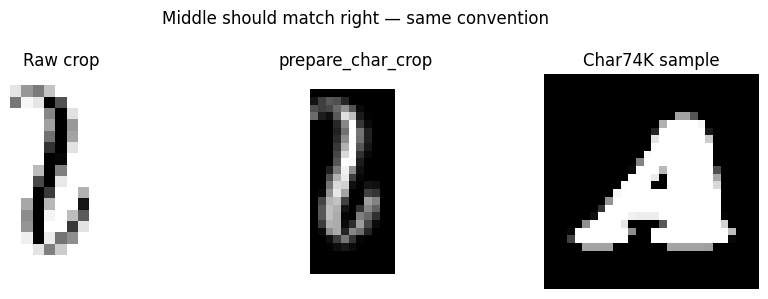

In [56]:
# Check what a prepared crop looks like vs what CNN expects
import matplotlib.pyplot as plt

# Get one crop
test_path = "/content/drive/MyDrive/OCR/Dataset/clean_images_grayscale/FontLre_Clean_TE.png"
raw      = cv2.imread(test_path, cv2.IMREAD_GRAYSCALE)
denoised = denoise_image(unet_model, raw, device)
binary   = preprocess_for_segmentation(denoised, method="sauvola", use_dilation=True)
seg      = extract_character_crops(denoised, binary)
crop     = seg[0]["char_crops"][2]  # grab a clear character

# Show raw crop vs prepared crop
prepared = prepare_char_crop(crop)
prepared_show = prepared * 0.3317 + 0.1736  # unnormalise

# Also show what Char74K looks like after __getitem__
char74k_img = cv2.imread(
    glob.glob("/content/English/Fnt/Sample011/*.png")[0],
    cv2.IMREAD_GRAYSCALE
)
char74k_processed = 255 - cv2.resize(char74k_img, (28, 28))

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(crop,              cmap="gray"); axes[0].set_title("Raw crop");      axes[0].axis("off")
axes[1].imshow(prepared_show,     cmap="gray"); axes[1].set_title("prepare_char_crop"); axes[1].axis("off")
axes[2].imshow(char74k_processed, cmap="gray"); axes[2].set_title("Char74K sample"); axes[2].axis("off")
plt.suptitle("Middle should match right — same convention")
plt.tight_layout()
plt.show()

In [57]:
# Upload a printed document — typed text, not handwritten
from google.colab import files
print("Upload a PRINTED document image (typed text, not handwritten):")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

result = run_ocr(img_path, unet_model, cnn_model, device, show=True)

Upload a PRINTED document image (typed text, not handwritten):


KeyboardInterrupt: 

Top 5 predictions:
  'm': 49.3%
  'M': 6.3%
  'n': 3.3%
  'R': 2.1%
  'p': 2.1%


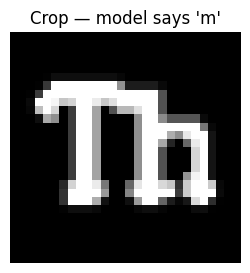

In [93]:
# Test on a single known character crop
# Take the first character from first line — should be 'T' from "There"
crop = seg[0]["char_crops"][0]

prepared   = prepare_char_crop(crop)
tensor     = torch.tensor(prepared, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    probs = torch.softmax(cnn_model(tensor), dim=1)

# Top 5 predictions
top5_vals, top5_idx = probs[0].topk(5)
print("Top 5 predictions:")
for val, idx in zip(top5_vals, top5_idx):
    print(f"  '{IDX_TO_CHAR[idx.item()]}': {val.item():.1%}")

# Show the crop
prepared_show = prepared * 0.3317 + 0.1736
plt.figure(figsize=(3, 3))
plt.imshow(prepared_show, cmap="gray")
plt.title(f"Crop — model says '{IDX_TO_CHAR[probs[0].argmax().item()]}'")
plt.axis("off")
plt.show()

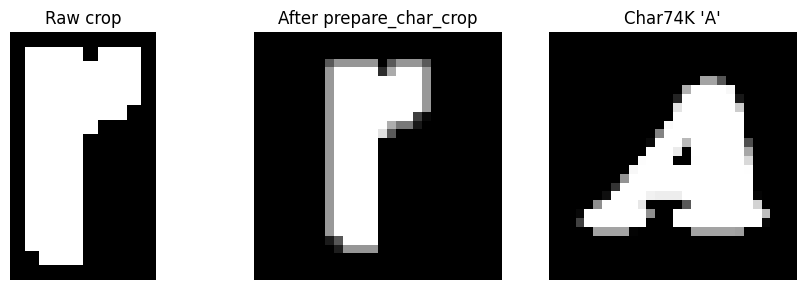

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

# Raw crop from document
axes[0].imshow(crop, cmap="gray")
axes[0].set_title("Raw crop")
axes[0].axis("off")

# After prepare_char_crop
prepared_show = prepared * 0.3317 + 0.1736
axes[1].imshow(prepared_show, cmap="gray")
axes[1].set_title("After prepare_char_crop")
axes[1].axis("off")

# What 'A' looks like in Char74K
import glob
a_img = cv2.imread(
    glob.glob("/content/English/Fnt/Sample011/*.png")[0],
    cv2.IMREAD_GRAYSCALE
)
a_img = cv2.resize(a_img, (28, 28))
a_img = 255 - a_img  # invert
axes[2].imshow(a_img, cmap="gray")
axes[2].set_title("Char74K 'A'")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [120]:
# Force redefine — overwrite old version in memory
def extract_character_crops(gray, binary, pad=2):
    H, W    = binary.shape
    results = []
    for (ly1, ly2) in segment_lines(binary):
        char_boxes_local  = segment_characters_in_line(binary[ly1:ly2, :])
        char_boxes_global = []
        char_crops        = []
        for (x, y, w, h) in char_boxes_local:
            x1 = max(0, x - pad)
            y1 = max(0, ly1 + y - pad)
            x2 = min(W, x + w + pad)
            y2 = min(H, ly1 + y + h + pad)
            char_boxes_global.append((x1, y1, x2, y2))
            char_crops.append(binary[y1:y2, x1:x2])  # binary not gray
        results.append({
            "line_box":   (ly1, ly2),
            "char_boxes": char_boxes_global,
            "char_crops": char_crops,
        })
    return results

# Verify it works
test_path = "/content/drive/MyDrive/OCR/Dataset/clean_images_grayscale/FontLre_Clean_TE.png"
raw       = cv2.imread(test_path, cv2.IMREAD_GRAYSCALE)
denoised  = denoise_image(unet_model, raw, device)
binary    = preprocess_for_segmentation(denoised, method="sauvola", use_dilation=True)
seg       = extract_character_crops(denoised, binary)
crop      = seg[0]["char_crops"][0]

print(f"Crop mean: {crop.mean():.1f}")
print(f"Expected: ~56 (white text on black)")

  No scaling needed — char height 22px
Crop mean: 67.7
Expected: ~56 (white text on black)


Saving Screenshot 2026-04-25 at 5.29.07 PM.png to Screenshot 2026-04-25 at 5.29.07 PM (1).png
  Upscaled 1.80x — char height 10px → 18px
Binary mean: 26.5 — WHITE on black ✓


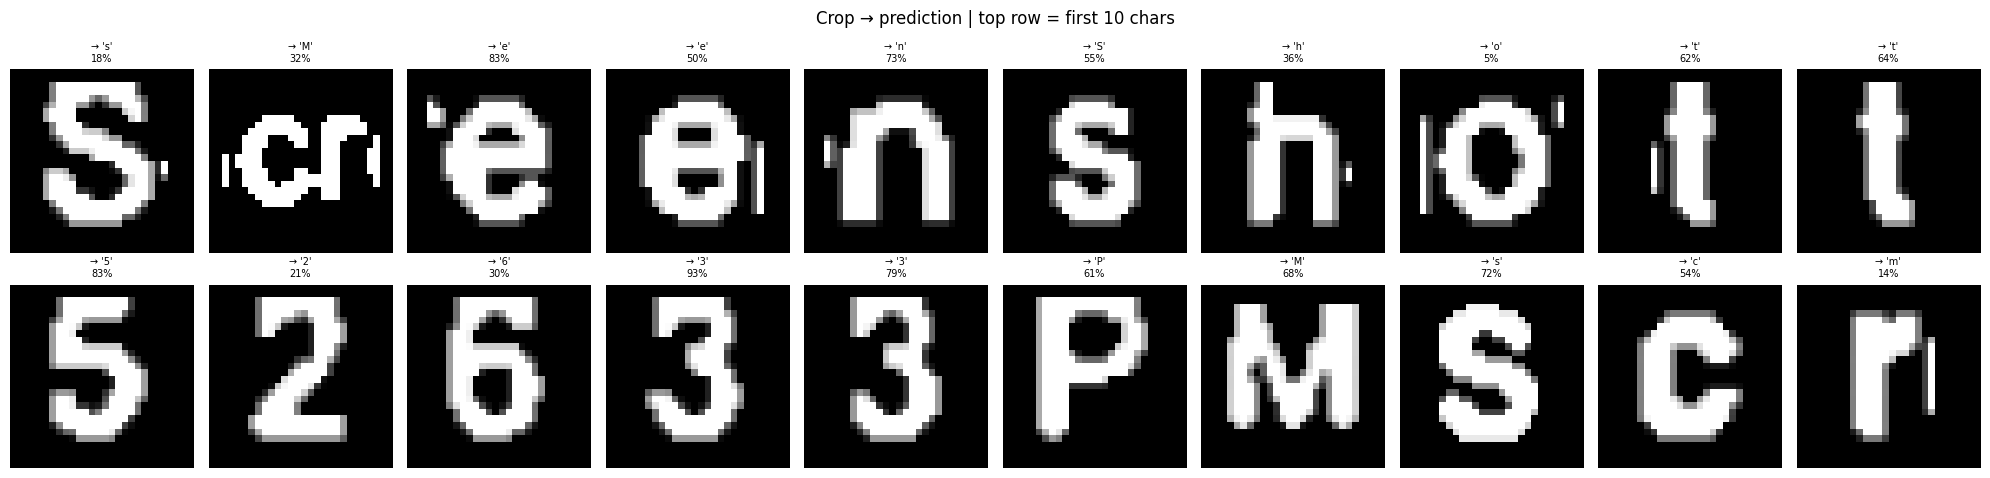

In [121]:
from google.colab import files
uploaded  = files.upload()
img_path  = list(uploaded.keys())[0]

raw      = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
denoised = denoise_image(unet_model, raw, device)
binary   = preprocess_for_segmentation(denoised, method="sauvola", use_dilation=False)

print(f"Binary mean: {binary.mean():.1f} — {'WHITE on black ✓' if binary.mean() < 127 else 'BLACK on white ✗'}")

seg        = extract_character_crops(binary, binary)  # ← binary, binary
crops_flat = []
for line in seg:
    crops_flat.extend(line["char_crops"])

n_show = min(20, len(crops_flat))
fig, axes = plt.subplots(2, 10, figsize=(20, 5))

for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis("off")
        continue
    crop     = crops_flat[i]
    prepared = prepare_char_crop(crop)  # ← no invert argument
    tensor   = torch.tensor(prepared, dtype=torch.float32)\
                   .unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        probs     = torch.softmax(cnn_model(tensor), dim=1)
        conf, idx = probs.max(dim=1)
    show = prepared * 0.3317 + 0.1736
    ax.imshow(show, cmap="gray")
    ax.set_title(f"→ '{IDX_TO_CHAR.get(idx.item(), '?')}'\n{conf.item():.0%}", fontsize=7)
    ax.axis("off")

plt.suptitle("Crop → prediction | top row = first 10 chars")
plt.tight_layout()
plt.show()

Saving Screenshot 2026-04-25 at 5.26.33 PM.png to Screenshot 2026-04-25 at 5.26.33 PM (3).png


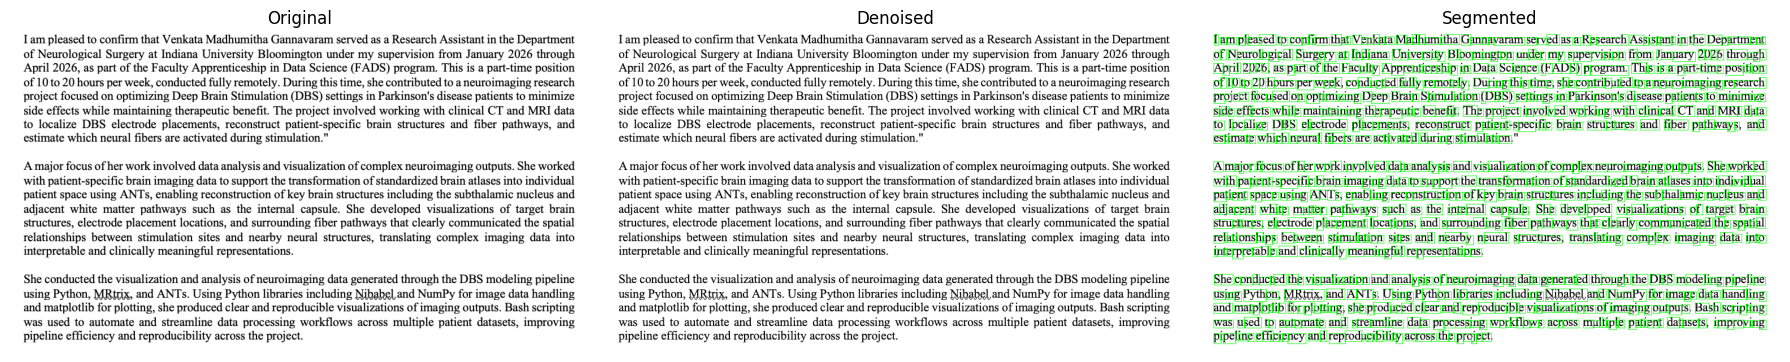

  Space threshold: 21.6px (max gap: 5.0px)
  Space threshold: 2.0px (max gap: 7.0px)
  Space threshold: 21.6px (max gap: 9.0px)
  Space threshold: 6.0px (max gap: 9.0px)
  Space threshold: 21.6px (max gap: 5.0px)
  Space threshold: 7.0px (max gap: 9.0px)
  Space threshold: 3.5px (max gap: 14.0px)
  Space threshold: -4.0px (max gap: 6.0px)
  Space threshold: 6.5px (max gap: 9.0px)
  Space threshold: 21.6px (max gap: 6.0px)
  Space threshold: 7.0px (max gap: 9.0px)
  Space threshold: 2.5px (max gap: 14.0px)
  Space threshold: 7.5px (max gap: 10.0px)
  Space threshold: 4.0px (max gap: 14.0px)
  Space threshold: 2.0px (max gap: 5.0px)
  Space threshold: 21.6px (max gap: 5.0px)
  Space threshold: 7.5px (max gap: 10.0px)
  Space threshold: 6.5px (max gap: 10.0px)
  Space threshold: 3.5px (max gap: 13.0px)
  Space threshold: 2.0px (max gap: 4.0px)
── OCR Output ──────────────────────────────
lamnlMM1ownh1mma1venkamMadhm1mGmnamHmdBaRcwhMs1stW1lntkenmen1
of NmIoAcd smeY al lndlm Un1mB1ty BlMm1n

In [126]:
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
result   = run_ocr(img_path, unet_model, cnn_model, device,
                   space_multiplier=1.8, show=True)

In [127]:
import os
import cv2
import numpy as np
import torch

# ── CER function ─────────────────────────────────────────────
def character_error_rate(ground_truth, predicted):
    gt   = ground_truth.strip()
    pred = predicted.strip()
    m, n = len(gt), len(pred)
    dp   = np.zeros((m + 1, n + 1))
    for i in range(m + 1): dp[i][0] = i
    for j in range(n + 1): dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if gt[i-1] == pred[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
    return round(float(dp[m][n]) / max(len(gt), 1), 4)


# ── Ground truth — first few lines of NoisyOffice clean docs ─
# Add as many as you want
ground_truths = {
    "Fontfse_Clean_TE.png": "There are several classic spatial filters high frequency noise from images",
    "Fontfre_Clean_TE.png": "A new offline handwritten database for the Spanish language which contains full Spanish sentences",
}

# ── Run evaluation ────────────────────────────────────────────
CLEAN_DIR = "/content/drive/MyDrive/OCR/Dataset/clean_images_grayscale"
results   = []

for filename, gt_text in ground_truths.items():
    img_path = os.path.join(CLEAN_DIR, filename)
    if not os.path.exists(img_path):
        print(f"Skipping {filename} — not found")
        continue

    # Run your pipeline
    raw      = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    denoised = denoise_image(unet_model, raw, device)
    binary   = preprocess_for_segmentation(denoised, method="sauvola", use_dilation=False)
    seg      = extract_character_crops(binary, binary)

    lines_out = []
    for line in seg:
        preds = []
        for crop in line["char_crops"]:
            prepared = prepare_char_crop(crop)
            tensor   = torch.tensor(prepared, dtype=torch.float32)\
                           .unsqueeze(0).unsqueeze(0).to(device)
            with torch.no_grad():
                probs     = torch.softmax(cnn_model(tensor), dim=1)
                conf, idx = probs.max(dim=1)
            preds.append(IDX_TO_CHAR.get(idx.item(), "?"))
        line_text = reconstruct_line_with_spaces(line["char_boxes"], preds)
        lines_out.append(line_text)

    predicted = " ".join(lines_out)
    cer       = character_error_rate(gt_text, predicted)
    results.append(cer)

    print(f"\n{filename}")
    print(f"  Ground truth: {gt_text[:60]}...")
    print(f"  Predicted:    {predicted[:60]}...")
    print(f"  CER:          {cer:.1%}")

# ── Summary ───────────────────────────────────────────────────
if results:
    print(f"\n── Summary ──────────────────────────")
    print(f"  Images evaluated: {len(results)}")
    print(f"  Mean CER:         {np.mean(results):.1%}")
    print(f"  Best CER:         {np.min(results):.1%}")
    print(f"  Worst CER:        {np.max(results):.1%}")
    print(f"  Char accuracy:    {(1 - np.mean(results)):.1%}")

  Space threshold: 19.8px (max gap: 5.0px)
  Space threshold: 3.0px (max gap: 16.0px)
  Space threshold: 15.5px (max gap: 22.0px)
  Space threshold: 7.0px (max gap: 13.0px)
  Space threshold: 9.0px (max gap: 11.0px)
  Space threshold: 15.0px (max gap: 20.0px)
  Space threshold: 19.8px (max gap: 9.0px)
  Space threshold: 19.8px (max gap: 6.0px)
  Space threshold: 6.0px (max gap: 9.0px)
  Space threshold: 11.0px (max gap: 13.0px)
  Space threshold: 19.8px (max gap: 7.0px)

Fontfse_Clean_TE.png
  Ground truth: There are several classic spatial filters high frequency noi...
  Predicted:    AnwohiKnehaRdwKrrmdatabaRhwEkSPR5hkngxH8e RnRmK has meRrly b...
  CER:          536.5%
  Space threshold: 12.6px (max gap: 16.0px)
  Space threshold: 16.5px (max gap: 19.0px)
  Space threshold: 19.0px (max gap: 21.0px)
  Space threshold: 16.0px (max gap: 19.0px)
  Space threshold: 15.0px (max gap: 21.0px)
  Space threshold: 28.0px (max gap: 34.0px)
  Space threshold: 16.2px (max gap: 15.0px)
  Space thre

In [128]:
# Use clean image OCR output as ground truth
# Run OCR on clean image
clean_path = "/content/drive/MyDrive/OCR/Dataset/clean_images_grayscale/Fontntm_Clean_TE.png"
noisy_path = "/content/drive/MyDrive/OCR/Dataset/simulated_noisy_images_grayscale/Fontntm_Noisef_TE.png"

# Ground truth = OCR on clean image
raw_clean    = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)
binary_clean = preprocess_for_segmentation(raw_clean, method="sauvola", use_dilation=False)
seg_clean    = extract_character_crops(binary_clean, binary_clean)

gt_lines = []
for line in seg_clean:
    preds = []
    for crop in line["char_crops"]:
        prepared = prepare_char_crop(crop)
        tensor   = torch.tensor(prepared, dtype=torch.float32)\
                       .unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            idx = cnn_model(tensor).argmax(dim=1).item()
        preds.append(IDX_TO_CHAR.get(idx, "?"))
    gt_lines.append(reconstruct_line_with_spaces(line["char_boxes"], preds))
ground_truth = " ".join(gt_lines)

# Predicted = OCR on noisy image
raw_noisy    = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
denoised     = denoise_image(unet_model, raw_noisy, device)
binary_noisy = preprocess_for_segmentation(denoised, method="sauvola", use_dilation=False)
seg_noisy    = extract_character_crops(binary_noisy, binary_noisy)

pred_lines = []
for line in seg_noisy:
    preds = []
    for crop in line["char_crops"]:
        prepared = prepare_char_crop(crop)
        tensor   = torch.tensor(prepared, dtype=torch.float32)\
                       .unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            idx = cnn_model(tensor).argmax(dim=1).item()
        preds.append(IDX_TO_CHAR.get(idx, "?"))
    pred_lines.append(reconstruct_line_with_spaces(line["char_boxes"], preds))
predicted = " ".join(pred_lines)

cer = character_error_rate(ground_truth, predicted)
print(f"Ground truth (clean): {ground_truth[:80]}")
print(f"Predicted (noisy):    {predicted[:80]}")
print(f"CER: {cer:.1%}")
print(f"Char accuracy: {(1-cer):.1%}")

  Space threshold: 5.5px (max gap: 12.0px)
  Space threshold: 18.0px (max gap: 24.0px)
  Space threshold: 5.5px (max gap: 15.0px)
  Space threshold: 24.5px (max gap: 37.0px)
  Space threshold: 29.0px (max gap: 35.0px)
  Space threshold: 18.0px (max gap: 24.0px)
  Space threshold: 5.5px (max gap: 12.0px)
  Space threshold: 24.0px (max gap: 35.0px)
  Space threshold: 6.5px (max gap: 13.0px)
  Space threshold: 21.6px (max gap: 0.0px)
  Space threshold: 5.5px (max gap: 12.0px)
  Space threshold: 18.0px (max gap: 24.0px)
  Space threshold: 24.0px (max gap: 36.0px)
  Space threshold: 24.5px (max gap: 36.0px)
  Space threshold: 24.0px (max gap: 35.0px)
  Space threshold: 5.5px (max gap: 12.0px)
  Space threshold: 18.0px (max gap: 24.0px)
  Space threshold: 5.5px (max gap: 15.0px)
  Space threshold: 24.5px (max gap: 37.0px)
  Space threshold: 29.0px (max gap: 35.0px)
  Space threshold: 18.0px (max gap: 24.0px)
  Space threshold: 5.5px (max gap: 12.0px)
  Space threshold: 24.0px (max gap: 35.0p